#### Validation strategy:
Our train set has 6 columns (index, molecule_name, atom_index_0, atom_index_1, type, scalar_coupling_constant)
molecule always have more than 1 atom so molecule_name isn't unique in table and just splitting dataset randomly will cause data leakage because the same molecule can be in both datasets. So we used GroupKFold to split it by molecule_name (80% went to train set and 20% to validation)

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dipole = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/dipole_moments.csv'))
structures = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/structures.csv'))
scalar_coupling_contributions = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/scalar_coupling_contributions.csv'))
magnetic_shielding_tensors = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/magnetic_shielding_tensors.csv'))
mulliken_charges = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/mulliken_charges.csv'))
potential_energy = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/potential_energy.csv'))
samples = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/sample_submission.csv'))
test = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/test.csv'))
train = pd.read_csv(Path('/kaggle/input/competitions/champs-scalar-coupling/train.csv'))


In [4]:
train.head()

,id,molecule_name,atom_index_0,atom_index_1,type,scalar_coupling_constant
0,0,dsgdb9nsd_000001,1,0,1JHC,84.8076
1,1,dsgdb9nsd_000001,1,2,2JHH,-11.2570
2,2,dsgdb9nsd_000001,1,3,2JHH,-11.2548
3,3,dsgdb9nsd_000001,1,4,2JHH,-11.2543
4,4,dsgdb9nsd_000001,2,0,1JHC,84.8074


In [5]:
train.shape

(4659076, 6)

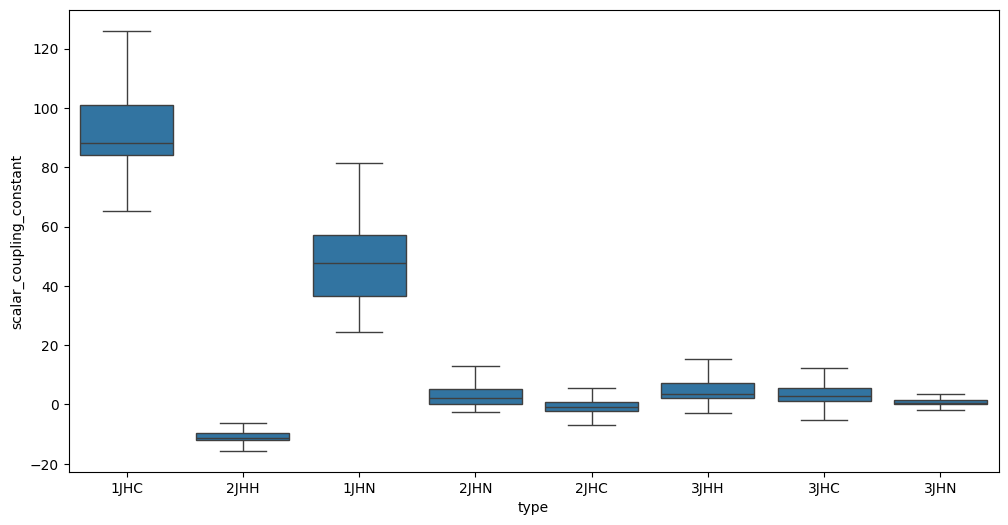

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='scalar_coupling_constant', data=train, showfliers=False)
plt.show()

In [7]:
from sklearn.model_selection import GroupKFold
splits=GroupKFold(n_splits=5)
train['fold']=-999
for fold, (train_idx, val_idx) in enumerate(splits.split(train, groups=train['molecule_name'])):
    train.loc[val_idx, 'fold'] = fold

In [8]:
print(train['fold'].value_counts())

fold
3    931816
1    931815
4    931815
2    931815
0    931815
Name: count, dtype: int64


In [13]:
train_fold = train[train['fold'] != 0].copy()
val_fold = train[train['fold'] == 0].copy()

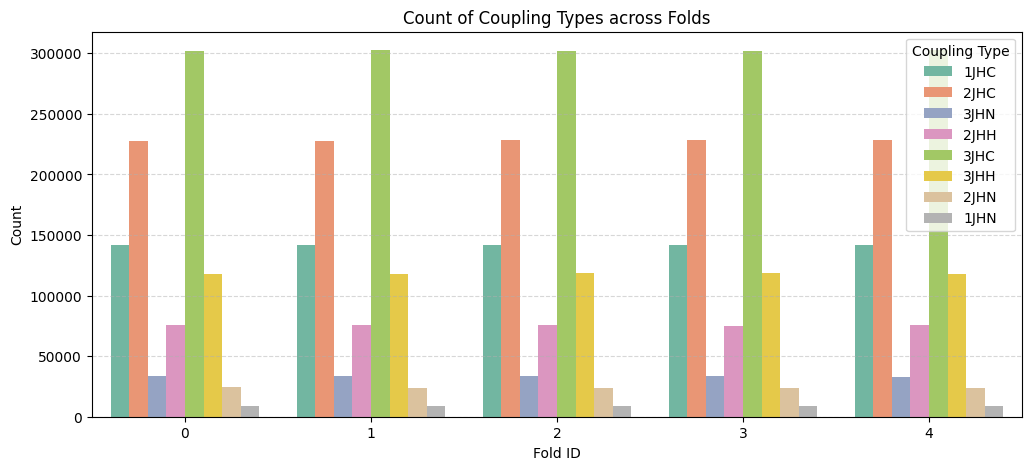

In [10]:
plt.figure(figsize=(12, 5))
sns.countplot(data=train, x="fold", hue="type", palette="Set2")
plt.title("Count of Coupling Types across Folds")
plt.xlabel("Fold ID")
plt.ylabel("Count")
plt.legend(title="Coupling Type")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

train_fold["is_val"] = 0
val_fold["is_val"] = 1

adv_train = train_fold.sample(n=100000, random_state=50)
adv_val = val_fold.sample(n=100000, random_state=50)
adv_df = pd.concat([adv_train, adv_val], axis=0).reset_index(drop=True)
features = [ col for col in adv_df.columns if col not in ["id", "molecule_name", "scalar_coupling_constant","fold","is_val"]]

X = pd.get_dummies(adv_df[features], drop_first=True)
y = adv_df["is_val"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50, stratify=y)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=50)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score, roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)

print(f"Adversarial ROC-AUC Score: {auc:.4f}")
print(f"Adversarial Accuracy Score: {acc:.4f}")

Adversarial ROC-AUC Score: 0.4960
Adversarial Accuracy Score: 0.4972


Our adversarial ROC-AUC score is 0.496(ideally 0.5). This means Random Forest model cannot distinguish between our training fold and validation fold, It proves that split successfully avoided data leakage.